# Bank Marketing Campaign Prediction (Deep Learning)

## Project Overview
This project builds a deep learning model to predict whether a customer will subscribe to a term deposit based on marketing campaign data.

## Business Objective
Optimize marketing efforts by identifying high-probability subscribers.

## Dataset
Bank marketing dataset containing customer demographic and campaign-related features.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('/content/bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


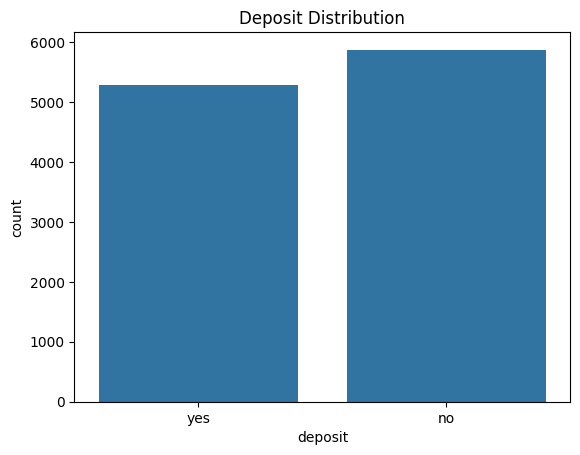

In [7]:
sns.countplot(x='deposit', data=df)
plt.title("Deposit Distribution")
plt.show()

In [8]:
df['deposit'] = df['deposit'].map({'yes':1,'no':0})

In [9]:
cat_col = df.select_dtypes(include=['object']).columns

In [10]:
le = LabelEncoder()

In [11]:
for col in cat_col:
  df[col] = le.fit_transform(df[col])

In [12]:
X = df.drop('deposit', axis= 1)
y = df['deposit']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size= 0.2, random_state=42)

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model= Sequential([
    Dense(64, input_shape=(16,), activation = 'relu'),
    Dropout(0.3),
    Dense(32, activation ='relu'),
    Dropout(0.3),
    Dense(16, activation = 'relu'),
    Dense(1, activation='sigmoid')


])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss = 'binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True

)

In [18]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6007 - loss: 0.6582 - val_accuracy: 0.7951 - val_loss: 0.4653
Epoch 2/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7797 - loss: 0.4869 - val_accuracy: 0.8085 - val_loss: 0.4364
Epoch 3/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7937 - loss: 0.4744 - val_accuracy: 0.8147 - val_loss: 0.4257
Epoch 4/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7966 - loss: 0.4515 - val_accuracy: 0.8141 - val_loss: 0.4274
Epoch 5/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8023 - loss: 0.4495 - val_accuracy: 0.8197 - val_loss: 0.4251
Epoch 6/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8035 - loss: 0.4410 - val_accuracy: 0.8124 - val_loss: 0.4239
Epoch 7/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8085 - loss: 0.4348 - val_accuracy: 0.8152 - val_loss: 0.4260
Epoch 8/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8017 - loss: 0.4378 - val_accu

Evaluate model

In [19]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss:     {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7915 - loss: 0.4467
Test Loss:     0.4140
Test Accuracy: 0.8128


In [20]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [21]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[929 237]
 [181 886]]
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1166
           1       0.79      0.83      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



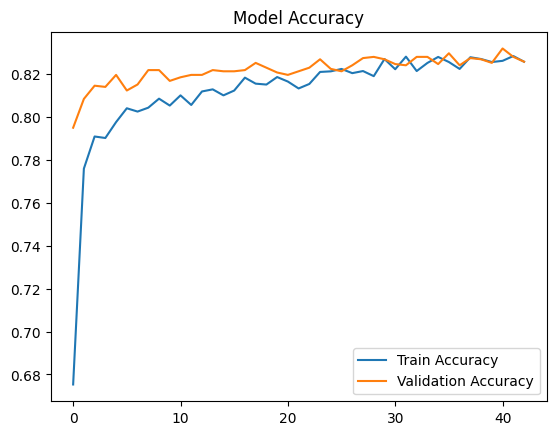

In [22]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()